In [44]:
import pandas as pd
# install rocket
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sktime.classification.kernel_based import RocketClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
# load csv TS_NO_OUTLIERS
df = pd.read_csv('TS_NO_OUTLIERS.csv')

In [46]:

# Analisi preliminare del target
print("Distribuzione delle classi nel target 'rating_category':")
print(df['rating_category'].value_counts())
print(f"\nNumero di classi uniche: {df['rating_category'].nunique()}")

# Encoding del target se necessario

# Prepara le features (escludi il target e eventuali colonne non numeriche)
# Time series soslo colonnne con numeri nel nome della colonna
columns_with_numbers = [col for col in df.columns if any(char.isdigit() for char in col)]
print(f"Colonne con numeri: {columns_with_numbers}")

Distribuzione delle classi nel target 'rating_category':
rating_category
2    387
4    361
3    226
1    128
0     10
Name: count, dtype: int64

Numero di classi uniche: 5
Colonne con numeri: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99']


In [47]:

X = df[columns_with_numbers].select_dtypes(include=[np.number])

print(f"Shape dei dati: {X.shape}")
print(f"Features utilizzate: {list(X.columns)}")

# ROCKET richiede che i dati siano in formato 3D (n_samples, n_features, n_timepoints)
# Se i tuoi dati sono già una serie temporale multivariata:
X_rocket = X.values.reshape(X.shape[0], 1, X.shape[1])

# Oppure se ogni riga rappresenta una serie temporale:
# X_rocket = X.values.reshape(X.shape[0], X.shape[1], 1)

print(f"Shape per ROCKET: {X_rocket.shape}")

Shape dei dati: (1112, 100)
Features utilizzate: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99']
Shape per ROCKET: (1112, 1, 100)


In [48]:
# Prima devi definire y (target)
y = df['rating_category'].values

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_rocket, y, test_size=0.2, random_state=42, stratify=y
)

# Z transform per normalizzare i dati
from scipy.stats import zscore

X_train = zscore(X_train, axis=0)
X_test = zscore(X_test, axis=0)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Inizializza ROCKET Classifier
rocket_classifier = RocketClassifier(
    num_kernels=40000,  # Numero di kernel casuali
    random_state=42
)

print("Training ROCKET Classifier...")
# Fit direttamente sui dati di training (non fit_transform)
rocket_classifier.fit(X_train, y_train)

print("Predizione con ROCKET Classifier...")
# Predici direttamente sui dati di test
y_pred_rocket = rocket_classifier.predict(X_test)

# Calcola accuracy
accuracy_rocket = accuracy_score(y_test, y_pred_rocket)
print(f"Accuracy ROCKET Classifier: {accuracy_rocket:.4f}")

print("\nClassification Report (ROCKET):")
print(classification_report(y_test, y_pred_rocket))

Training set: (889, 1, 100)
Test set: (223, 1, 100)
Training ROCKET Classifier...
Predizione con ROCKET Classifier...
Accuracy ROCKET Classifier: 0.4215

Classification Report (ROCKET):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.25      0.31      0.28        26
           2       0.48      0.50      0.49        78
           3       0.21      0.16      0.18        45
           4       0.53      0.56      0.54        72

    accuracy                           0.42       223
   macro avg       0.29      0.30      0.30       223
weighted avg       0.41      0.42      0.41       223



/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

In [49]:
# import stratified KFold
from sklearn.model_selection import StratifiedKFold, cross_val_score
# Usa StratifiedKFold per mantenere la distribuzione delle classi
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation scores
cv_scores = cross_val_score(
    rocket_classifier, 
    X_train, 
    y_train, 
    cv=cv, 
    scoring='f1_macro',
    n_jobs=-1  # Per parallelizzare
)

print(f"Cross-validation scores (ROCKET): {cv_scores}")

rocket_classifier.fit(X_train, y_train)

print("Predizione con ROCKET Classifier...")
# Predici direttamente sui dati di test
y_pred_rocket = rocket_classifier.predict(X_test)

# Calcola accuracy
accuracy_rocket = accuracy_score(y_test, y_pred_rocket)
print(f"Accuracy ROCKET Classifier: {accuracy_rocket:.4f}")

print("\nClassification Report (ROCKET):")
print(classification_report(y_test, y_pred_rocket))


Cross-validation scores (ROCKET): [0.32500686 0.31048176 0.25693323 0.26861615 0.30158508]
Predizione con ROCKET Classifier...
Accuracy ROCKET Classifier: 0.4215

Classification Report (ROCKET):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.25      0.31      0.28        26
           2       0.48      0.50      0.49        78
           3       0.21      0.16      0.18        45
           4       0.53      0.56      0.54        72

    accuracy                           0.42       223
   macro avg       0.29      0.30      0.30       223
weighted avg       0.41      0.42      0.41       223



/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

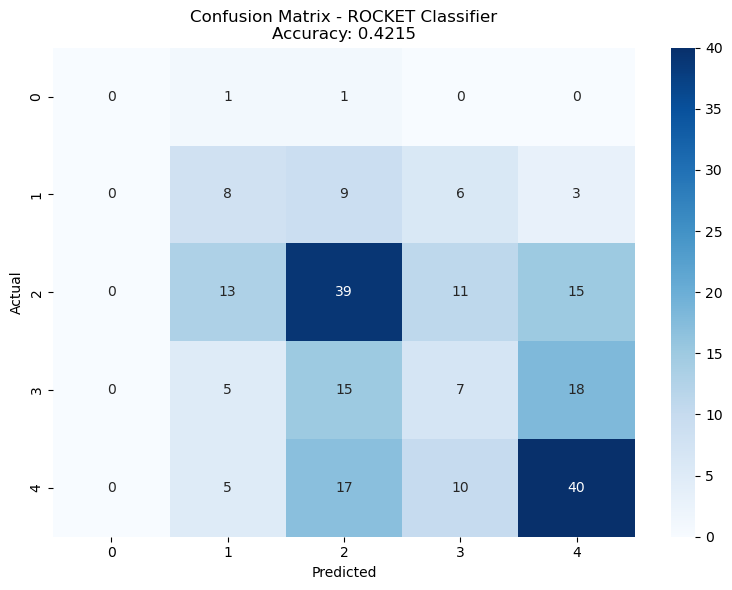

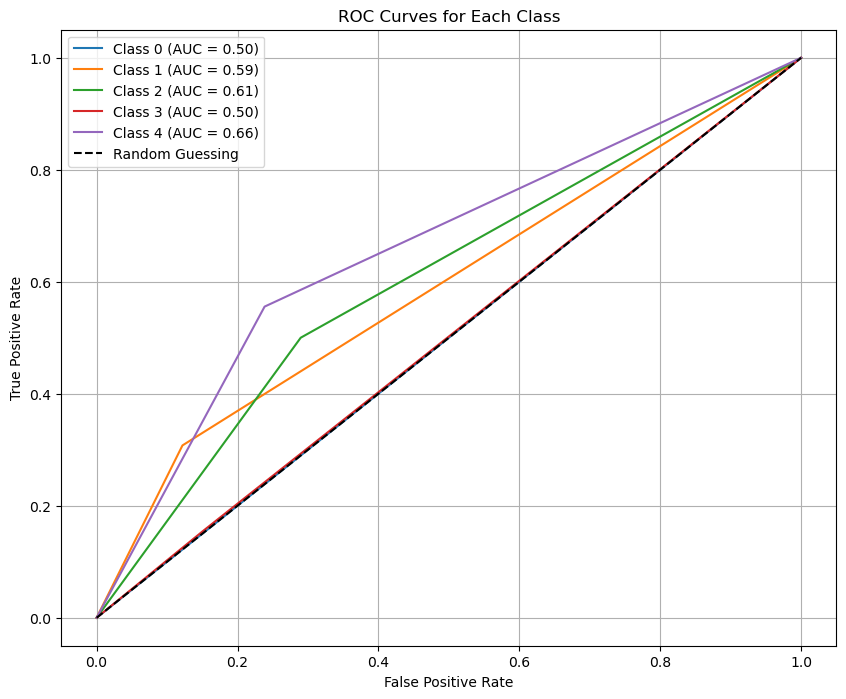

In [50]:
# Visualizzazione dei risultati
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Confusion Matrix per ROCKET
cm_rocket = confusion_matrix(y_test, y_pred_rocket)
unique_labels = np.unique(y)
sns.heatmap(cm_rocket, annot=True, fmt='d', cmap='Blues', 
            xticklabels=unique_labels, yticklabels=unique_labels, ax=ax)
ax.set_title(f'Confusion Matrix - ROCKET Classifier\nAccuracy: {accuracy_rocket:.4f}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# roc curves
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
# Binarizza le etichette per ROC curve
y_bin = label_binarize(y_test, classes=np.unique(y))
# Calcola le curve ROC per ogni classe
fpr = {}
tpr = {}
roc_auc = {}
for i in range(y_bin.shape[1]):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_pred_rocket == i)
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot delle curve ROC
plt.figure(figsize=(10, 8))
for i in range(y_bin.shape[1]):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.title('ROC Curves for Each Class')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()
